In [42]:
import pickle
import scipy.signal
from scipy import signal
import h5py
import numpy as np


In [53]:
def load_ssvep_data(file_path):
    """
    Load EEG-Data and Trigger from .mat v7.3 (HDF5)
    
    As I tried it with loadmat from scipy.io I had the following error
    "NotImplementedError: Please use HDF reader for matlab v7.3 files, e.g. h5py"
    Thats why I use h5py
    """
    with h5py.File(file_path, "r") as f:
       # print(list(f.keys())) # check keys name - its "y" thats why I use y below
       # print(f["y"].shape)
        raw_data = f["y"][:]    # get the real np.ndarray from the data          
        eegs     = raw_data[:, 1:9]       # CH2 bis CH9 → EEG
        triggers = raw_data[:, 9]         # CH10 → Trigger (LED on/off)

    return eegs, triggers

# load data
eeg_data, trigger_data = load_ssvep_data("ssvep/subject_1_fvep_led_training_1.mat")
#print(trigger_data)

print("EEG shape:", eeg_data.shape)
print("Trigger shape:", trigger_data.shape)
# mne - maybe transponse to (n_channels, n_samples) - for ICA, CSP etc

EEG shape: (57728, 8)
Trigger shape: (57728,)


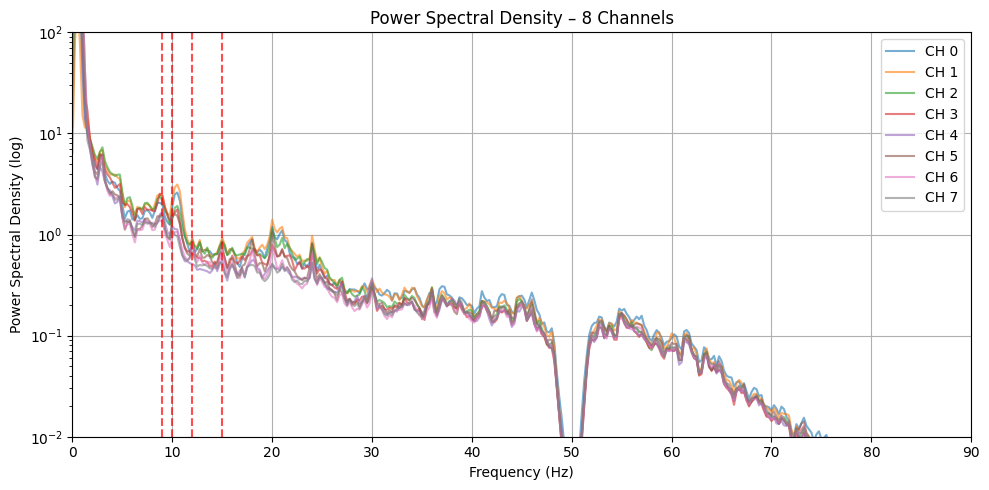

In [ ]:
# Power Spectral Density (PSD) Analysis

import matplotlib.pyplot as plt
from scipy.signal import welch

plt.figure(figsize=(10, 5))


for ch in range(eeg_data.shape[1]):
    freqs, psd = welch(eeg_data[:, ch], fs=256, nperseg=1024)
    plt.semilogy(freqs, psd, label=f"CH {ch}", alpha=0.6)
# *** but why nperseg=1024? 
# SO we want to separate 9Hz from 10Hz 
# delta f = sampling_rate / points_count
# points_count = 256 (sampling rate) * 4 (seconds) = 1024
# then delta f = 256 / 1024 = 0.25 
# - meaning we cannot distinguish between 10Hz and 10.25Hz anymore
# but thats ok as we want to separate 9Hz from 10Hz (1 Hz difference < 0.25)

# SSVEP-Frequencies
for target_freq in [9, 10, 12, 15]:
    plt.axvline(x=target_freq, color='red', linestyle='--', alpha=0.7)

plt.xlim(0, 90)  # x - Frequency
plt.ylim(1e-2, 1e2)  # y - Power 
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (log)")
plt.title("Power Spectral Density – 8 Channels")
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


# Notch Filter at 50Hz already applied
# Peak at 20 Hz - 2. harmonics for 10Hz or artefact? muscel activity?

In [ ]:
# Just to know the duration of data
sfreq = 256.0 #sampling rate
duration_seconds = len(eeg_data) / 256
print("Duration in seconds:", duration_seconds)
print("...in minutes:", duration_seconds / 60)


Duration in seconds: 225.5
...in minutes: 3.7583333333333333


In [54]:
# we want to work with data in MNE compatible format, so..
import mne

eeg_data = eeg_data.T # transpose for MNE

# Channels from Montagepicture
ch_names = ["PO7", "PO3", "POz", "PO4", "PO8", "O1", "Oz", "O2"]
ch_types = ["eeg"] * 8

# Info-Objekt for MNE
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)

# RawArray 
# with raw.get_data() - (n_channels, n_samples)
raw = mne.io.RawArray(eeg_data, info) #so it is MNE compatible

# Montage:
# I suppose the name from https://mne.tools/stable/auto_tutorials/intro/40_sensor_locations.html
raw.set_montage("standard_1020")



Creating RawArray with float64 data, n_channels=8, n_times=57728
    Range : 0 ... 57727 =      0.000 ...   225.496 secs
Ready.


<RawArray | 8 x 57728 (225.5 s), ~3.5 MiB, data loaded>

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1.1e+02 - 1.3e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 110.00
- Lower transition bandwidth: 27.50 Hz (-6 dB cutoff frequency: 96.25 Hz)
- Upper passband edge: 127.00 Hz
- Upper transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 127.50 Hz)
- Filter length: 845 samples (3.301 s)

Setting 91 of 57728 (0.16%) samples to NaN, retaining 57637 (99.84%) samples.
Setting up low-pass filter at 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff

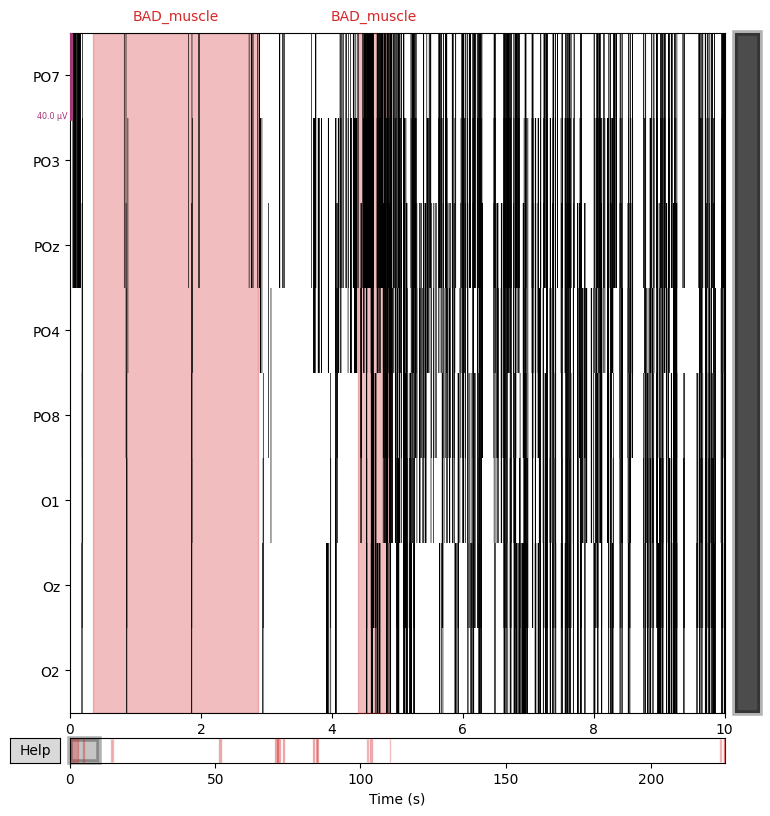

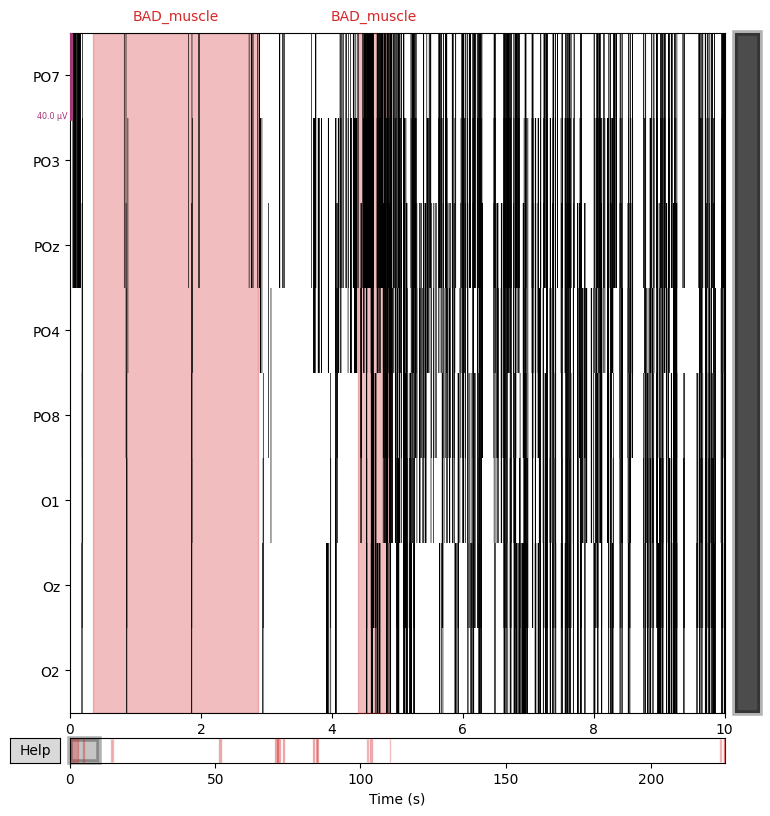

In [68]:
# Plot the muscle artefacts with annotate_muscle_zscore()

# Why threshold = 4 ? Just took it from https://mne.tools/stable/generated/mne.preprocessing.annotate_muscle_zscore.html
annotations, scores = mne.preprocessing.annotate_muscle_zscore(
    raw, ch_type="eeg", threshold=4.0,  filter_freq=(110, 127)
)
raw.set_annotations(annotations)
raw.plot()

In [56]:
# SO WHERE ARE THE MUSCLE ARTEFACTS?
# more about: https://mne.tools/stable/generated/mne.Annotations.html
print(raw.annotations)
print(raw.annotations.onset)       # starttime in sec
print(raw.annotations.duration)    # duration in seconds

# so we have muscle artefact at the beginning ---> cut it out


<Annotations | 1 segment: BAD_muscle (1)>
[0.]
[0.3671875]


In [60]:
# Check the raw Object with all the Data
print("Samplingrate:", raw.info['sfreq'], "Hz")
print("Channels:", raw.ch_names)
print("Channel types:", raw.get_channel_types())
print("Form:", raw.get_data().shape)
print("Duration:", raw.times[-1], "seconds")
print("Montage:", raw.get_montage())
raw.info


Samplingrate: 256.0 Hz
Channels: ['PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2']
Channel types: ['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']
Form: (8, 57728)
Duration: 225.49609375 seconds
Montage: <DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 8 channels>


<Info | 8 non-empty values
 bads: []
 ch_names: PO7, PO3, POz, PO4, PO8, O1, Oz, O2
 chs: 8 EEG
 custom_ref_applied: False
 dig: 11 items (3 Cardinal, 8 EEG)
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 8
 projs: []
 sfreq: 256.0 Hz
>

In [ ]:
# bandpass filter
raw_filtered = raw.copy().filter(l_freq=6.0, h_freq=30.0)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 6 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 6.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 423 samples (1.652 s)

